### The notebook is for diff types of classification trees.

In [145]:
library(rsample)     # data splitting 
library(dplyr)       # data wrangling
library(rpart)       # performing regression trees
library(rpart.plot)  # plotting regression trees
library(ipred)       # bagging
library(caret)       # bagging
library(smotefamily)
library(janitor) 
library(readr)
library(tidyverse)
library(caret)
library(xgboost)

We set some global parmeter for the tree model.

In [146]:
# DATA RELATED PARAMS
def_outbreak = 2 # number of cases to be considered as outbreak
perc_strata = 0.75 # proportion of data to be used for training
# SMOTE RELATED PARAMS
K_neighbors = 5 # number of nearest neighbors
Ratio_testtrain = 0 # for 50/50 outbreak/non-outbreak

#### THIS SECTION IS FOR PREPARING DATA

The following code block is for loading the data and splitting it into training and testing sets. This is done with createDataPartition to ensure approx same distribution and we assume a place with outbreak has to have more than 2 cases.

In [147]:
set.seed(100)

df <- read_csv("data/merged_data.csv") |> clean_names() 

# outbreak >=2 is with outbreak, vice versa.
df$outbreak <- as.integer(df$outbreak >= def_outbreak)

# split the data with stratified sampling
strata <- ifelse(df$outbreak > 0, "nonzero", "zero")
index <- createDataPartition(strata, p = perc_strata, list = FALSE)
train <- df[index,]
test <- df[-index,]
head(train)

Rows: 254 Columns: 405
-- Column specification --------------------------------------------------------
Delimiter: ","
chr   (1): County
dbl (381): cve, outbreak, enrollment, population, PHR, pct_hispanic, pct_bla...
lgl  (23): median_income, Advised to Cut Down Salt - Do not use salt, Diabet...

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


county,cve,outbreak,enrollment,population,phr,pct_hispanic,pct_black,pct_white,pct_poverty,...,up_to_date_cervical_cancer_s_no,up_to_date_cervical_cancer_s_yes,up_to_date_cervical_cancer_s_2_no,up_to_date_cervical_cancer_s_2_yes,v_col_5_yrs_50_75_ia_no,v_col_5_yrs_50_75_ia_yes,v_col_5_yrs_age_50_75_no,v_col_5_yrs_age_50_75_yes,virtual_colonoscopy_no,virtual_colonoscopy_yes
<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Anderson,2.54,0,7808,60303,4,19.6,18.6,58.3,13.5,...,NA,NA,NA,NA,92.8,NA,92.8,NA,72.4,NA
Angelina,2.50,0,15649,87492,5,23.5,12.1,63.4,11.5,...,36.9,63.1,36.8,63.2,92.2,NA,92.3,NA,65.5,34.5
Armstrong,5.24,0,297,1806,1,12.0,0.6,89.9,6.0,...,39.9,60.1,40.0,60.0,96.9,NA,96.9,NA,76.0,NA
Austin,3.55,0,6290,32958,6,27.8,7.9,66.6,10.6,...,39.2,60.8,39.1,60.9,97.0,NA,97.0,NA,74.3,25.7
Bailey,0.80,1,1330,7057,1,66.0,0.9,71.3,7.4,...,39.9,60.1,40.0,60.0,96.9,NA,96.9,NA,76.0,NA
Bandera,3.78,0,2461,22918,8,21.0,1.2,77.2,8.5,...,28.4,71.6,28.3,71.7,96.4,NA,96.3,NA,80.6,19.4


SMOTE function only takes in numeric data and unfortunately removing all NAs by row will remove all the counties. This code block is for pleasing SMOTE to work. We first remove county col as it is the only one with str, and then we remove all cols containing any flavor of NAs.

In [148]:
train <- train[, colSums(is.na(train)) == 0]
train <- train[, !names(train) %in% c("county")]

This code block is for creating artificial data for training using SMOTE method (fundamentally introducing noise) and balancing between the two class.

In [149]:
set.seed(42)
# K for controlling the neighborhood, dup_size for ratio to achieve
smote_output <- SMOTE(
  X      = train[, names(train) != "outbreak"],
  target = train$outbreak,
  K      = K_neighbors, 
  dup_size = Ratio_testtrain
)

train_balanced <- smote_output$data
# SMOTE put target data in "class" col and rename it
names(train_balanced)[names(train_balanced) == "class"] <- "outbreak"
train_balanced$outbreak <- as.factor(train_balanced$outbreak)
cat("\nClass balance after SMOTE:\n")
print(table(train_balanced$outbreak))
head(train_balanced)
# mirror on test set
test <- test[, colSums(is.na(test)) == 0]
test <- test[, !names(test) %in% c("county")]
test$outbreak <- as.factor(test$outbreak)


Class balance after SMOTE:

  0   1 
174 162 


cve,population,phr,pct_hispanic,pct_black,pct_white,pct_poverty,pct_uninsured,pct_college,pct_foreign_born,...,teeth_removed_no,teeth_removed_yes,up_to_date_crc_scrn_50_75_ia_no,up_to_date_crc_scrn_50_75_ia_yes,up_to_date_crc_scrn_age_50_7_no,up_to_date_crc_scrn_age_50_7_yes,v_col_5_yrs_50_75_ia_no,v_col_5_yrs_age_50_75_no,virtual_colonoscopy_no,outbreak
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1.88,15034,9,85.3,1.8,38.8,13.3,17.5,7.4,1.6,...,60.4,39.6,37.6,62.4,37.6,62.4,92.8,92.8,72.2,1
1.60,175677,9,63.5,4.5,48.1,14.0,22.1,17.6,1.8,...,60.4,39.6,37.6,62.4,37.6,62.4,92.8,92.8,72.2,1
0.80,7057,1,66.0,0.9,71.3,7.4,28.6,15.2,3.7,...,55.6,44.4,32.8,67.2,32.4,67.6,96.9,96.9,76.0,1
1.30,31802,1,61.3,4.6,52.6,15.9,21.0,15.3,0.7,...,55.6,44.4,32.8,67.2,32.4,67.6,96.9,96.9,76.0,1
2.90,21620,1,50.2,3.4,57.2,11.0,19.1,18.9,0.8,...,55.6,44.4,32.8,67.2,32.4,67.6,96.9,96.9,76.0,1
3.99,18223,2,17.3,2.2,80.8,10.5,15.3,21.8,0.6,...,49.8,50.2,29.8,70.2,29.8,70.2,98.1,98.1,86.1,1


#### THIS SECTION IS UNTUNED MODEL

The analysis is for untuned model. The code block is for decision tree, it is almost without tuning except for the cp parameter.

In [150]:
# set decision tree
dtree_model <- rpart(outbreak ~ ., data = train_balanced, method = "class")

# eval performance s
pred <- predict(dtree_model, newdata = train, type = "class")

dtree_table <- table(Actual = train$outbreak, Predicted = pred)
dtree_table

      Predicted
Actual   0   1
     0 159  15
     1   4  14

This code is for random forest without param tuning

In [151]:
library(randomForest)

# TODO we also need mtry
c = 0.4 #how many trees need to agree

rforest_model <- randomForest(outbreak ~ ., data = train_balanced, ntree = 500, importance = TRUE)

pred <- predict(rforest_model, newdata = train, type = "class", cutoff=c(c, 1-c))
rforest_table <- table(Actual = train$outbreak, Predicted = pred)
rforest_table

# Mean decreased accuracy basically says if a variable is omitted, how much does the mean accurary decrease by
# Mean decreased gini measures how often the varaible is used to slip data into classes 
#importance(model)



      Predicted
Actual   0   1
     0 165   9
     1   8  10

This code block is for XGBoost without param tuning which is a gradient based method. We use it than usual boosting because we have large amount of covariates and it is more efficient.

      Predicted
Actual   0   1
     0 174   0
     1   0  18

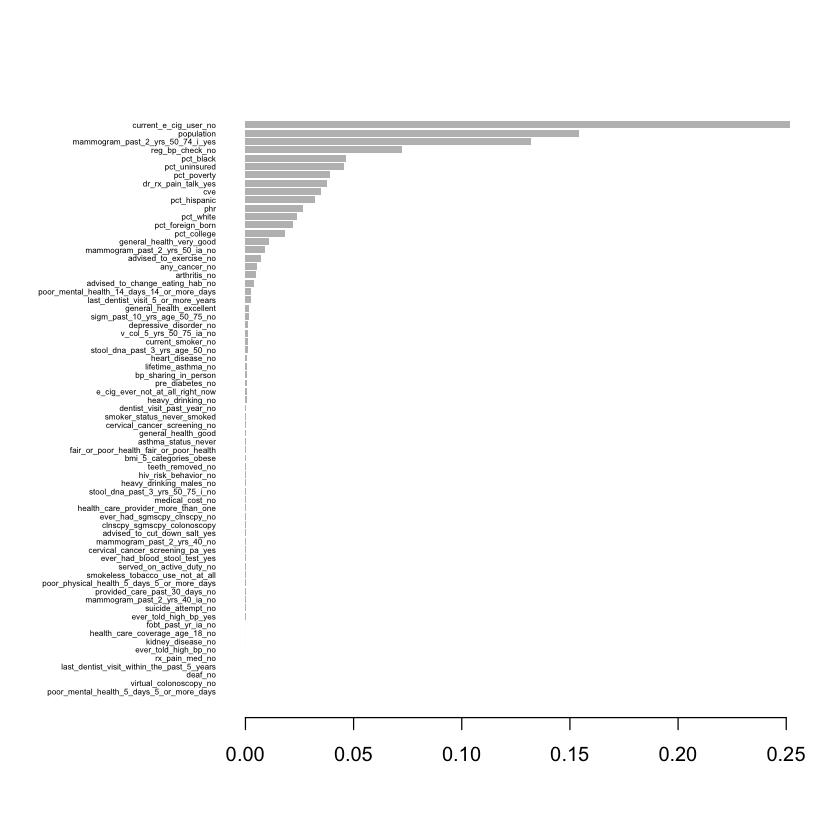

In [152]:
# boos: The algorithm draws a bootstrap sample of the training data in each iteration using the weights for each observation. 
# Misclassified or harder-to-predict samples receive higher weights, meaning they are 
# more likely to be selected for the next tree's training data

# mfinal: number of iterations

# TODO: add control bc it uses rpart each iteration
# Prepare matrices for xgb boost
X_train <- as.matrix(train_balanced[, names(train_balanced) != "outbreak"])
y_train <- as.numeric(as.character(train_balanced$outbreak))

X_test  <- as.matrix(train[, names(train) != "outbreak"])
y_test  <- as.numeric(as.character(train$outbreak))

dtrain  <- xgb.DMatrix(data = X_train, label = y_train)
dtest   <- xgb.DMatrix(data = X_test,  label = y_test)

boost_model <- xgb.train(
  params = list(
    objective   = "multi:softmax",
    eval_metric = "mlogloss",
    num_class   = 2,
    max_depth   = 3,
    eta         = 0.1
  ),
  data    = dtrain,
  nrounds = 500
)

pred <- as.factor(predict(boost_model, dtest))

boost_table <- table(Actual = as.factor(y_test), Predicted = pred)
boost_table

# importance graph
importance_matrix <- xgb.importance(model = boost_model)
xgb.plot.importance(importance_matrix)

This gives a quick comparison between the model accuracy

In [153]:
get_accuracy <- function(eval_table) {
  round(sum(diag(eval_table)) / sum(eval_table) * 100, 2)
}

results <- data.frame(
  Model    = c("Decision Tree (rpart)", "Random Forest", "XGBoost (softmax)"),
  Cutoff   = c("default", c, "default"),
  Accuracy = c(
    get_accuracy(dtree_table),
    get_accuracy(rforest_table),
    get_accuracy(boost_table)
  )
)

results$Best     <- ifelse(results$Accuracy == max(results$Accuracy), "<--", "")

print(results, row.names = FALSE)

                 Model  Cutoff Accuracy Best
 Decision Tree (rpart) default    90.10     
         Random Forest     0.4    91.15     
     XGBoost (softmax) default   100.00  <--


#### THIS SECTION IS FOR TUNED MODEL

We set some param for tuning the tree model here.

In [ ]:
FNlosses <- c(seq(1, 10, by=0.1))
cp0 <- -1
cutoffs <- c(seq(0.2, 0.5, by=0.1))


The following code block are set for auto select parameters for the classification tree model. We tune on penalty for false negative and the complexity parameter. We use 10 fold cross validation to select the best parameters.

In [175]:
modsTree <- vector(mode="list", length=length(FNlosses))
# Tune FN loss with cp0 = -1
for(FNloss in FNlosses){
    set.seed(4)
    j <- which(FNlosses==FNloss)
    modsTree[[j]] <- rpart(outbreak ~ ., 
    data = train_balanced, 
    method = "class", 
    parms=list(loss=matrix(c(0,FNloss,1,0), nrow=2)), weights = ceiling(train_balanced$population), cp=cp0)
}

# Tune on cp with optimal cp from 10-fold CV
results <- data.frame()

for(j in 1:length(FNlosses)){
  # Get optimal cp for this tree via built-in CV
  cp_table <- modsTree[[j]]$cptable
  opt_cp <- cp_table[which.min(cp_table[,"xerror"]), "CP"]
  
  # Prune
  pruned <- prune(modsTree[[j]], cp = opt_cp)
  
  # eval on train
  preds <- predict(pruned, newdata = train_balanced, type = "class")
  cm <- table(Actual = train_balanced$outbreak, Predicted = preds)
  
  # Extract precision for outbreak class
  precision <- cm[2,2] / sum(cm[,2])
  recall    <- cm[2,2] / sum(cm[2,])
  
  results <- rbind(results, data.frame(
    FNloss = FNlosses[j],
    opt_cp = opt_cp,
    precision = precision,
    recall = recall
  ))
}

print(results)


   FNloss       opt_cp precision    recall
1     1.0 0.0000000000 0.9316770 0.9259259
2     1.1 0.0000000000 0.9171598 0.9567901
3     1.2 0.0044807416 0.9303797 0.9074074
4     1.3 0.0038604877 0.9303797 0.9074074
5     1.4 0.0033288414 0.9303797 0.9074074
6     1.5 0.0000000000 0.9171598 0.9567901
7     1.6 0.0000000000 0.9171598 0.9567901
8     1.7 0.0021091824 0.9000000 0.9444444
9     1.8 0.0000000000 0.9064327 0.9567901
10    1.9 0.0015100517 0.9000000 0.9444444
11    2.0 0.0012554212 0.9000000 0.9444444
12    2.1 0.0011624371 0.9000000 0.9444444
13    2.2 0.0012300990 0.9000000 0.9444444
14    2.3 0.0012977608 0.9000000 0.9444444
15    2.4 0.0013654227 0.9000000 0.9444444
16    2.5 0.0014330845 0.9000000 0.9444444
17    2.6 0.0015007463 0.9000000 0.9444444
18    2.7 0.0015684082 0.9000000 0.9444444
19    2.8 0.0016360700 0.9000000 0.9444444
20    2.9 0.0017037319 0.9000000 0.9444444
21    3.0 0.0017713937 0.9000000 0.9444444
22    3.1 0.0018390556 0.9000000 0.9444444
23    3.2 0

We then tune on random forest. We would tune on mtry and c. mtry is worth tuning in our case because there is a large set of correlated covariates.

In [180]:
mtrys <- c(5, 10, 15, 20, 25, 30, 35, 40, 45, 50)   
cutoffs <- c(0.2, 0.3, 0.4, 0.5)

results_rf <- data.frame()

for(m in mtrys){
  for(c_val in cutoffs){
    rf <- randomForest(outbreak ~ .,
                       data = train_balanced,
                       mtry = m,
                       ntree = 500,
                       cutoff = c(c_val, 1-c_val))
    
    preds <- predict(rf, newdata = train_balanced, type = "class")
    cm <- table(Actual = train_balanced$outbreak, Predicted = preds)
    
    precision <- cm[2,2] / sum(cm[,2])
    recall    <- cm[2,2] / sum(cm[2,])
    
    results_rf <- rbind(results_rf, data.frame(
      mtry = m,
      cutoff = c_val,
      precision = precision,
      recall = recall
    ))
  }
}

print(results_rf)

   mtry cutoff precision    recall
1     5    0.2 0.9316770 0.9259259
2     5    0.3 0.8882353 0.9320988
3     5    0.4 0.8728324 0.9320988
4     5    0.5 0.8728324 0.9320988
5    10    0.2 0.9741935 0.9320988
6    10    0.3 0.9437500 0.9320988
7    10    0.4 0.9207317 0.9320988
8    10    0.5 0.8882353 0.9320988
9    15    0.2 0.9869281 0.9320988
10   15    0.3 0.9741935 0.9320988
11   15    0.4 0.9556962 0.9320988
12   15    0.5 0.9263804 0.9320988
13   20    0.2 0.9934211 0.9320988
14   20    0.3 0.9869281 0.9320988
15   20    0.4 0.9743590 0.9382716
16   20    0.5 0.9451220 0.9567901
17   25    0.2 0.9934211 0.9320988
18   25    0.3 0.9869281 0.9320988
19   25    0.4 0.9811321 0.9629630
20   25    0.5 0.9751553 0.9691358
21   30    0.2 1.0000000 0.9320988
22   30    0.3 0.9935897 0.9567901
23   30    0.4 0.9873418 0.9629630
24   30    0.5 0.9753086 0.9753086
25   35    0.2 1.0000000 0.9320988
26   35    0.3 1.0000000 0.9629630
27   35    0.4 0.9936709 0.9691358
28   35    0.5 0.981

We then tune for XGBoost.

In [182]:
library(xgboost)

# Class imbalance weight
scale_weight <- sum(y_train==0) / sum(y_train==1)

# Define grid (keep manageable)
param_grid <- expand.grid(
  max_depth = c(3, 5, 7),
  eta       = c(0.01, 0.05, 0.1)
)
results_xgb <- data.frame()

for(i in 1:nrow(param_grid)){
  set.seed(4)
  
  model <- xgb.train(
    params = list(
      objective        = "binary:logistic",
      eval_metric      = "logloss",
      max_depth        = param_grid$max_depth[i],
      eta              = param_grid$eta[i],
      scale_pos_weight = scale_weight
    ),
    data    = dtrain,
    nrounds = 500,
    watchlist             = list(train=dtrain),
    early_stopping_rounds = 20,
    verbose               = 0
  )
  
  probs <- predict(model, dtrain)
  
  # Safe best_iteration
  best_iter <- ifelse(is.null(model$best_iteration), 500, model$best_iteration)
  
  for(thresh in c(0.3, 0.4, 0.5)){
    preds <- factor(ifelse(probs >= thresh, 1, 0), levels = c(0,1))
    actual <- factor(y_train, levels = c(0,1))
    cm <- table(Actual = actual, Predicted = preds)
    
    # Now cm always has 2x2 structure due to explicit levels
    precision <- cm[2,2] / sum(cm[,2])
    recall    <- cm[2,2] / sum(cm[2,])
    
    results_xgb <- rbind(results_xgb, data.frame(
      max_depth    = param_grid$max_depth[i],
      eta          = param_grid$eta[i],
      threshold    = thresh,
      best_nrounds = best_iter,
      precision    = precision,
      recall       = recall
    ))
  }
}

print(results_xgb)
best_xgb <- results_xgb[which.max(results_xgb$recall), ]
print(best_xgb)

Warning message in throw_err_or_depr_msg("Parameter '", match_old, "' has been renamed to '", :
"Parameter 'watchlist' has been renamed to 'evals'. This warning will become an error in a future version."
Warning message in throw_err_or_depr_msg("Parameter '", match_old, "' has been renamed to '", :
"Parameter 'watchlist' has been renamed to 'evals'. This warning will become an error in a future version."
Warning message in throw_err_or_depr_msg("Parameter '", match_old, "' has been renamed to '", :
"Parameter 'watchlist' has been renamed to 'evals'. This warning will become an error in a future version."
Warning message in throw_err_or_depr_msg("Parameter '", match_old, "' has been renamed to '", :
"Parameter 'watchlist' has been renamed to 'evals'. This warning will become an error in a future version."
Warning message in throw_err_or_depr_msg("Parameter '", match_old, "' has been renamed to '", :
"Parameter 'watchlist' has been renamed to 'evals'. This warning will become an error in

   max_depth  eta threshold best_nrounds precision    recall
1          3 0.01       0.3          500 0.9523810 0.9876543
2          3 0.01       0.4          500 0.9578313 0.9814815
3          3 0.01       0.5          500 0.9636364 0.9814815
4          5 0.01       0.3          500 0.9700599 1.0000000
5          5 0.01       0.4          500 0.9818182 1.0000000
6          5 0.01       0.5          500 0.9937888 0.9876543
7          7 0.01       0.3          500 0.9818182 1.0000000
8          7 0.01       0.4          500 0.9938650 1.0000000
9          7 0.01       0.5          500 1.0000000 0.9938272
10         3 0.05       0.3          500 1.0000000 1.0000000
11         3 0.05       0.4          500 1.0000000 1.0000000
12         3 0.05       0.5          500 1.0000000 1.0000000
13         5 0.05       0.3          500 1.0000000 1.0000000
14         5 0.05       0.4          500 1.0000000 1.0000000
15         5 0.05       0.5          500 1.0000000 1.0000000
16         7 0.05       